# Task 6.2 C
### Name: Nay Tun
### Student Id: 225110052
### Human code (with some light llm recommendation for code syntax)

In [101]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV,StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm


1. Define the classification task, what are the input variables and what is the output variable ? 

# Refering to this documentation - https://archive.ics.uci.edu/dataset/878/cirrhosis+patient+survival+prediction+dataset-1
### Below table shows the features and target of the dataset
|Column|Description|Role|
|--------------------|------------------------------------------------------|----------|
|ID|unique identifier|None|
|N_Days|number of days between registration and the earlier of death, transplantation, or study analysis time in July 1986|None|
|Status|status of the patient C (censored), CL (censored due to liver tx), or D (death)|Target|
|Drug|type of drug D-penicillamine or placebo|Feature|
|Age|age in [days]|Feature|
|Sex|M (male) or F (female)|Feature|
|Ascites|presence of ascites N (No) or Y (Yes)|Feature|
|Hepatomegaly|presence of hepatomegaly N (No) or Y (Yes)|Feature|
|Spiders|presence of spiders N (No) or Y (Yes)|Feature|
|Edema|presence of edema N (no edema and no diuretic therapy for edema), S (edema present without diuretics, or edema resolved by diuretics), or Y (edema despite diuretic therapy)|Feature|
|Bilirubin|serum bilirubin in [mg/dl]|Feature|
|Cholesterol|serum cholesterol in [mg/dl]|Feature|
|Albumin|albumin in [gm/dl]|Feature|
|Copper|urine copper in [ug/day]|Feature|
|Alk_Phos|alkaline phosphatase in [U/liter]|Feature|
|SGOT|SGOT in [U/ml]|Feature|
|Triglycerides|triglicerides in [mg/dl]|Feature|
|Platelets|platelets per cubic [ml/1000]|Feature|
|Prothrombin|prothrombin time in seconds [s]|Feature|
|Stage|histologic stage of disease (1, 2, 3, or 4)|Feature|

### Class Labels
##### Status: status of the patient 0 = D (death), 1 = C (censored), 2 = CL (censored due to liver transplantation)

# 2.  Load and explore the dataset.  
- a.  Use an appropriate method to deal with the missing values for the data set if there are.  
- b.  Split the data set into training and test set with a ratio of  (8:2). 
- c.  Based on the training and test data, show the feature types and indicate which features are continuous or categorical. 
- d.  Do necessary encoding for the categorical features if there are.  
- e.  Show the correlation between the features and the label, is there any strong or weak correlation? 

In [102]:
df = pd.read_csv("https://raw.githubusercontent.com/nay-deakin/sit720-data/refs/heads/main/cirrhosis.csv")
print (len(df))
df.head()

418


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


### Run code to see how we split the features into either Ordinal, Nominal or Numerical
### Also check which text column have how many unique values

##### First lets drop the ID, N_Days, Status from the X

# Categorical/nominal Features

In [103]:
for col in df.select_dtypes(include="object"):
    print (col, df[col].nunique(),list(df[col].unique()))

Status 3 ['D', 'C', 'CL']
Drug 2 ['D-penicillamine', 'Placebo', nan]
Sex 2 ['F', 'M']
Ascites 2 ['Y', 'N', nan]
Hepatomegaly 2 ['Y', 'N', nan]
Spiders 2 ['Y', 'N', nan]
Edema 3 ['Y', 'N', 'S']


In [104]:
X = df.drop(columns = ['ID', 'N_Days', 'Status'])
y = df['Status'].map({'D': 0, 'C': 1, 'CL': 2})

Looking at the result all the Text Columns should be Classfied as nominal. Does not look like there are any Ordinal feature.

In [105]:
ordinal_cols = []
numeric_cols = list(X.select_dtypes(include=['float64', 'int64']).columns)
nominal_cols = [col for col in list(X.select_dtypes(include="object")) if col not in ordinal_cols]
print (f"Numeric/conitinous cols: {numeric_cols}")
print (f"Nominal/categorical cols: {nominal_cols}")


Numeric/conitinous cols: ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Nominal/categorical cols: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']


### Check how many features have missing columns

##### for the nominal missing values here are some options that I understood we can do to fill these values
- 1. Introduce unknown class (most simple)
- 2. Most frequent value (probably need domain knowledge to understand if this option is appropriate)
- 3. Use KNN to fill those missing values (more complex and for this assignment purpose I am not confident to use this)

In [106]:
# check for nominal fields
X[nominal_cols].isna().sum()

Drug            106
Sex               0
Ascites         106
Hepatomegaly    106
Spiders         106
Edema             0
dtype: int64

### For numeric I want to see if the features have normal distribution.
### If they do have a normal distribution then we can use the mean 
### If not normal just use the median

In [107]:
# check for numeric fields
X[numeric_cols].isna().sum()

Age                0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

In [108]:
from scipy import stats
for col in numeric_cols:
    stat, p_value = stats.shapiro(df.loc[df[col].notna(),col])
    print (f"{col} - Stat: {stat}, p-value: {p_value}")


Age - Stat: 0.9905685555207655, p-value: 0.00891823602558195
Bilirubin - Stat: 0.6319727022035107, p-value: 5.907596614700113e-29
Cholesterol - Stat: 0.6445412533510253, p-value: 6.423406971448646e-24
Albumin - Stat: 0.9865174130993514, p-value: 0.000638661217642514
Copper - Stat: 0.7874274325866399, p-value: 8.351096101930217e-20
Alk_Phos - Stat: 0.6133080030411227, p-value: 6.849605042082735e-26
SGOT - Stat: 0.9117846234304668, p-value: 1.4672197427503261e-12
Tryglicerides - Stat: 0.814995037565253, p-value: 1.2212851026131962e-17
Platelets - Stat: 0.9767836136065058, p-value: 4.207792059883966e-06
Prothrombin - Stat: 0.8494251503723549, p-value: 1.5903024200388233e-19
Stage - Stat: 0.841360709927238, p-value: 6.406701361873331e-20


# Split the data into train and test 80:20


In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

### Might use this for gridsearch later
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

### Based on the above results, non of them are normal.
### Age and Albumin is close to 1 bell shaped but p-value < 0.05
### The rest far from normal
### So fill with Medium

### Ok the plan now is to create 2 function and use them in the pipeline
### fill_nominal and fill_numerical, the first function is to fill na with unknown and the second is fill na

In [110]:
def fill_nominal(X, cols):
    X = X.copy()
    X[cols] = X[cols].fillna('unknown')
    return X

def fill_numerical(X, cols):
    X = X.copy()
    for col in cols:
        X[col] = X[col].fillna(X[col].median())
    return X



### Create a null imputer and pipeline -
- So for categorical it will fill null with 'unknown' and then do OHE
- For numerical it will fill null with median and use StandardScaler to scale the numbers

### The wrap everything up in a Preprocessor

In [111]:
null_imputer_nominal = FunctionTransformer(
    fill_nominal,
    kw_args = {'cols': nominal_cols},
    validate = False,
    feature_names_out = 'one-to-one'
)

null_imputer_numerical = FunctionTransformer(
    fill_numerical,
    kw_args = {'cols': numeric_cols},
    validate = False,
    feature_names_out = 'one-to-one'
)

nominal_pipeline = Pipeline([
    ('fill_nominal', null_imputer_nominal),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

numeric_pipeline = Pipeline([
    ('fill_numerical', null_imputer_numerical),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('nominal', nominal_pipeline, nominal_cols),
    ('numeric', numeric_pipeline, numeric_cols)
])

### Lets preprocess the features based on our pipeline and pre-processor

In [112]:

X_preproc = preprocessor.fit_transform(X_train,y_train)
x_features = preprocessor.get_feature_names_out()
X_preproc_df = pd.DataFrame(X_preproc, columns = x_features)
X_preproc_df['target'] = y_train.values
X_preproc_df.head()


,nominal__Drug_Placebo,nominal__Drug_unknown,nominal__Sex_M,nominal__Ascites_Y,nominal__Ascites_unknown,nominal__Hepatomegaly_Y,nominal__Hepatomegaly_unknown,nominal__Spiders_Y,nominal__Spiders_unknown,nominal__Edema_S,...,numeric__Cholesterol,numeric__Albumin,numeric__Copper,numeric__Alk_Phos,numeric__SGOT,numeric__Tryglicerides,numeric__Platelets,numeric__Prothrombin,numeric__Stage,target
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.495065,0.470290,2.340539,4.431481,1.263610,1.003534,-0.464326,0.239363,-0.020686,1
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,-0.223434,0.241248,-0.259386,-0.305076,-0.097573,-0.211143,0.790390,-0.341368,-0.020686,1
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,-0.223434,0.447385,-0.259386,-0.305076,-0.097573,-0.211143,-0.403121,0.045786,-0.020686,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.695214,0.813852,-0.321884,-0.733320,-1.382007,-0.932907,0.106927,0.336152,-2.323696,1
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.025115,-0.331356,-0.196888,-0.461675,-0.158737,0.985930,0.637376,0.432940,-1.172191,1


In [113]:
X_preproc_df.corr()

,nominal__Drug_Placebo,nominal__Drug_unknown,nominal__Sex_M,nominal__Ascites_Y,nominal__Ascites_unknown,nominal__Hepatomegaly_Y,nominal__Hepatomegaly_unknown,nominal__Spiders_Y,nominal__Spiders_unknown,nominal__Edema_S,...,numeric__Cholesterol,numeric__Albumin,numeric__Copper,numeric__Alk_Phos,numeric__SGOT,numeric__Tryglicerides,numeric__Platelets,numeric__Prothrombin,numeric__Stage,target
nominal__Drug_Placebo,1.000000,-0.428489,-0.051931,0.057959,-0.428489,0.291912,-0.428489,0.109785,-0.428489,-0.073079,...,0.066350,0.046001,0.053658,0.021482,0.060569,0.029912,0.038739,0.096240,0.077128,-0.051760
nominal__Drug_unknown,-0.428489,1.000000,-0.041625,-0.145367,1.000000,-0.456516,1.000000,-0.302001,1.000000,0.110601,...,-0.125394,-0.107069,-0.145571,-0.171213,-0.054759,-0.118496,-0.072666,0.019585,-0.027765,0.073525
nominal__Sex_M,-0.051931,-0.041625,1.000000,0.026474,-0.041625,0.063653,-0.041625,-0.098492,-0.041625,-0.014272,...,0.002010,0.036208,0.202730,0.041267,0.000890,0.076110,-0.091732,0.055863,0.003683,-0.080622
nominal__Ascites_Y,0.057959,-0.145367,0.026474,1.000000,-0.145367,0.217641,-0.145367,0.244876,-0.145367,0.002164,...,-0.038301,-0.322289,0.257815,0.043740,0.102558,0.216511,-0.162925,0.282859,0.221892,-0.278258
nominal__Ascites_unknown,-0.428489,1.000000,-0.041625,-0.145367,1.000000,-0.456516,1.000000,-0.302001,1.000000,0.110601,...,-0.125394,-0.107069,-0.145571,-0.171213,-0.054759,-0.118496,-0.072666,0.019585,-0.027765,0.073525
nominal__Hepatomegaly_Y,0.291912,-0.456516,0.063653,0.217641,-0.456516,1.000000,-0.456516,0.397711,-0.456516,0.055975,...,0.172432,-0.190952,0.292346,0.150680,0.134439,0.158896,-0.119003,0.150903,0.384610,-0.216156
nominal__Hepatomegaly_unknown,-0.428489,1.000000,-0.041625,-0.145367,1.000000,-0.456516,1.000000,-0.302001,1.000000,0.110601,...,-0.125394,-0.107069,-0.145571,-0.171213,-0.054759,-0.118496,-0.072666,0.019585,-0.027765,0.073525
nominal__Spiders_Y,0.109785,-0.302001,-0.098492,0.244876,-0.302001,0.397711,-0.302001,1.000000,-0.302001,0.099869,...,0.103415,-0.179953,0.318885,0.052718,0.118999,0.147963,-0.084891,0.164918,0.261515,-0.191133
nominal__Spiders_unknown,-0.428489,1.000000,-0.041625,-0.145367,1.000000,-0.456516,1.000000,-0.302001,1.000000,0.110601,...,-0.125394,-0.107069,-0.145571,-0.171213,-0.054759,-0.118496,-0.072666,0.019585,-0.027765,0.073525
nominal__Edema_S,-0.073079,0.110601,-0.014272,0.002164,0.110601,0.055975,0.110601,0.099869,0.110601,1.000000,...,-0.054012,-0.075738,0.041233,0.025492,-0.004303,0.140986,-0.105207,0.155457,0.147840,-0.104166


### Use SNS heatmap to show the correlation in a heatmap

<Axes: >

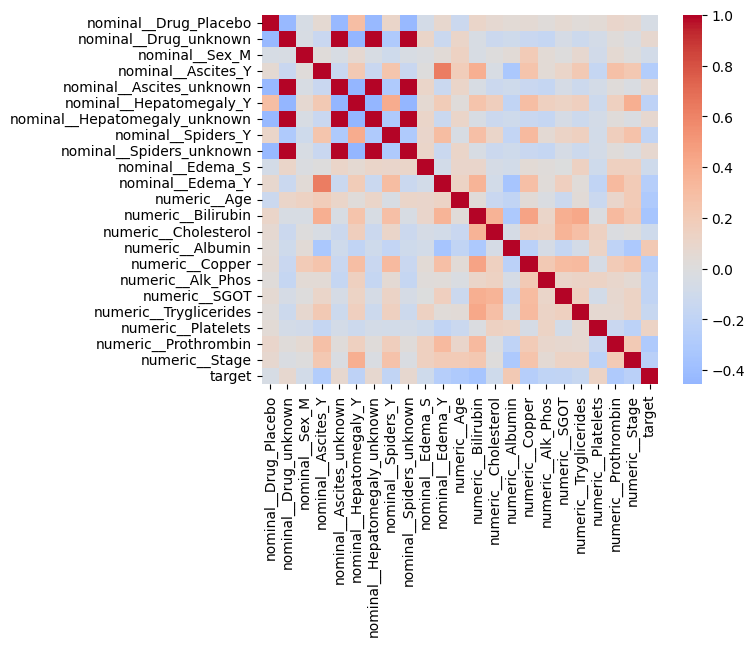

In [114]:
sns.heatmap(X_preproc_df.corr(), cmap='coolwarm', center=0)

# Strong correlation with Target:
- Albumin
- Platelets

# Weak correlation with Target:
- Bilirubim
- Prothrombin
- Copper

# Lets look at the Class balance

### Class mappint {'D': 0, 'C': 1, 'CL': 2}

In [115]:
df.groupby('Status')['Status'].count()/df['Status'].count()

Status
C     0.555024
CL    0.059809
D     0.385167
Name: Status, dtype: float64

### Based on the above data some class imbalance
|Class|Numeric Map|Percentage|
|------------|------------|---------------|
|D|0|~39%|
|C|1|~55%|
|CL|2|~6%|

### Class Labels
##### Status: status of the patient 0 = D (death), 1 = C (censored), 2 = CL (censored due to liver transplantation)


#

# 3.  Based on the pre-processed training data from question 1, create three supervised machine learning (ML) models for predicting the target variable.
                     
- a.  Use an appropriate validation method, report performance score using a suitable metric. Is it possible that the presented result is an underfitted or overfitted one Justify.   
- b.  Justify different design decisions for each ML model used to answer this question. 
- c.  Have you optimised any hyper-parameters for each ML model? What are they? Why have you done that? Explain.  
- d.  If the dataset is imbalanced, use a method to deal with the label imbalance  issue  and  indicate  whether  there  is  a  model improvement after you balance the dataset.  
- e.  Finally, make a model recommendation based on the reported results and justify it.

# Logistic Regression

In [116]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=1)),
])

## No Tuning

In [117]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.59      0.72        32
           1       0.71      0.94      0.81        47
           2       0.00      0.00      0.00         5

    accuracy                           0.75        84
   macro avg       0.54      0.51      0.51        84
weighted avg       0.74      0.75      0.72        84

[[19 13  0]
 [ 2 44  1]
 [ 0  5  0]]


# LR Grid Search

In [118]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

do_grid_search = True
if do_grid_search:
    param_grid = {
        'classifier__C':            [ 0.01, 0.1, 1, 10],
        'classifier__solver':       ['saga'],
        'classifier__penalty':      ['l1','l2'],
        'classifier__class_weight': [None, 'balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
        'classifier__max_iter': [10, 100, 200, 500, 1000]
    }

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)
    print(f"Best params: {grid_search.best_params_}")

Best params: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}


In [119]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=1
                                    , max_iter=grid_search.best_params_['classifier__max_iter']
                                    , C=grid_search.best_params_['classifier__C']
                                    , class_weight=grid_search.best_params_['classifier__class_weight']
                                    , penalty=grid_search.best_params_['classifier__penalty']
                                    , solver=grid_search.best_params_['classifier__solver']
        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.66      0.76        32
           1       0.76      0.72      0.74        47
           2       0.12      0.40      0.19         5

    accuracy                           0.68        84
   macro avg       0.60      0.59      0.56        84
weighted avg       0.78      0.68      0.72        84

[[21  8  3]
 [ 2 34 11]
 [ 0  3  2]]


# LR Grid Search based on StratifiedKfold

In [120]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

do_grid_search = True
if do_grid_search:
    param_grid = {
        'classifier__C':            [ 0.01, 0.1, 1, 10],
        'classifier__solver':       ['saga'],
        'classifier__penalty':      ['l1','l2'],
        'classifier__class_weight': [None, 'balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
        'classifier__max_iter': [10, 100, 200, 500, 1000]
    }

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=sss,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X, y)
    print(f"Best params: {grid_search.best_params_}")

Best params: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}


In [121]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=1
                                    , max_iter=grid_search.best_params_['classifier__max_iter']
                                    , C=grid_search.best_params_['classifier__C']
                                    , class_weight=grid_search.best_params_['classifier__class_weight']
                                    , penalty=grid_search.best_params_['classifier__penalty']
                                    , solver=grid_search.best_params_['classifier__solver']
        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.66      0.78        32
           1       0.76      0.81      0.78        47
           2       0.17      0.40      0.24         5

    accuracy                           0.73        84
   macro avg       0.63      0.62      0.60        84
weighted avg       0.80      0.73      0.75        84

[[21  9  2]
 [ 1 38  8]
 [ 0  3  2]]


In [122]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

do_grid_search = True
if do_grid_search:
    param_grid = {
        'classifier__C':            [ 0.01, 0.1, 1, 10],
        'classifier__solver':       ['saga'],
        'classifier__penalty':      ['l1','l2'],
        'classifier__class_weight': [None, 'balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
        'classifier__max_iter': [10, 100, 200, 500, 1000]
    }

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X, y)
    print(f"Best params: {grid_search.best_params_}")

Best params: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 200, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}


In [123]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=1
                                    , max_iter=grid_search.best_params_['classifier__max_iter']
                                    , C=grid_search.best_params_['classifier__C']
                                    , class_weight=grid_search.best_params_['classifier__class_weight']
                                    , penalty=grid_search.best_params_['classifier__penalty']
                                    , solver=grid_search.best_params_['classifier__solver']
        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.66      0.78        32
           1       0.76      0.81      0.78        47
           2       0.17      0.40      0.24         5

    accuracy                           0.73        84
   macro avg       0.63      0.62      0.60        84
weighted avg       0.80      0.73      0.75        84

[[21  9  2]
 [ 1 38  8]
 [ 0  3  2]]


#

# SVM (Support vector machine)

In [124]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC( random_state=1)),
])

### No Tuning

In [125]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.62      0.74        32
           1       0.73      0.96      0.83        47
           2       0.00      0.00      0.00         5

    accuracy                           0.77        84
   macro avg       0.54      0.53      0.52        84
weighted avg       0.75      0.77      0.74        84

[[20 12  0]
 [ 2 45  0]
 [ 0  5  0]]


# SVM Grid Search

In [126]:
# Generated by Claude
# the prompt is "Give some recommendation on SVM hyper tuning, also include kernel poly and degree in the mix"


do_grid_search = True
if do_grid_search:
    param_grid = [
        # ── RBF kernel ────────────────────────────────────────────
        {
            'classifier__kernel':       ['rbf'],
            'classifier__C':            [0.01, 0.1, 1, 10, 100],
            'classifier__gamma':        ['scale', 'auto', 0.001, 0.01],
            'classifier__class_weight': ['balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
            'classifier__max_iter': [10, 100, 200, 500, 1000]
        },
        # ── Poly kernel ───────────────────────────────────────────
        {
            'classifier__kernel':       ['poly'],
            'classifier__C':            [0.01, 0.1, 1, 10, 100],
            'classifier__degree':       [2, 3, 4, 6, 8],
            'classifier__gamma':        ['scale', 'auto'],
            'classifier__class_weight': ['balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
            'classifier__max_iter': [10, 100, 200, 500, 1000]
        },
        # ── Linear kernel ─────────────────────────────────────────
        {
            'classifier__kernel':       ['linear'],
            'classifier__C':            [0.01, 0.1, 1, 10, 100],
            'classifier__class_weight': ['balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
            'classifier__max_iter': [10, 100, 200, 500, 1000]
        },
    ]

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)
    print(f"Best params: {grid_search.best_params_}")

Best params: {'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf', 'classifier__max_iter': 200}


In [127]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(random_state=1
                                    , max_iter=grid_search.best_params_['classifier__max_iter']
                                    , C=grid_search.best_params_['classifier__C']
                                    , class_weight=grid_search.best_params_['classifier__class_weight']
                                    , gamma=grid_search.best_params_['classifier__gamma']
                                    , kernel=grid_search.best_params_['classifier__kernel']
        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.62      0.73        32
           1       0.75      0.70      0.73        47
           2       0.12      0.40      0.18         5

    accuracy                           0.65        84
   macro avg       0.58      0.58      0.54        84
weighted avg       0.76      0.65      0.69        84

[[20  9  3]
 [ 2 33 12]
 [ 1  2  2]]


# Grid search using stratified Kfold

In [128]:
# Generated by Claude
# the prompt is "Give some recommendation on SVM hyper tuning, also include kernel poly and degree in the mix"


do_grid_search = True
if do_grid_search:
    param_grid = [
        # ── RBF kernel ────────────────────────────────────────────
        {
            'classifier__kernel':       ['rbf'],
            'classifier__C':            [0.01, 0.1, 1, 10, 100],
            'classifier__gamma':        ['scale', 'auto', 0.001, 0.01],
            'classifier__class_weight': ['balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
            'classifier__max_iter': [10, 100, 200, 500, 1000]
        },
        # ── Poly kernel ───────────────────────────────────────────
        {
            'classifier__kernel':       ['poly'],
            'classifier__C':            [0.01, 0.1, 1, 10, 100],
            'classifier__degree':       [2, 3, 4, 6, 8],
            'classifier__gamma':        ['scale', 'auto'],
            'classifier__class_weight': ['balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
            'classifier__max_iter': [10, 100, 200, 500, 1000]
        },
        # ── Linear kernel ─────────────────────────────────────────
        {
            'classifier__kernel':       ['linear'],
            'classifier__C':            [0.01, 0.1, 1, 10, 100],
            'classifier__class_weight': ['balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
            'classifier__max_iter': [10, 100, 200, 500, 1000]
        },
    ]

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=sss,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)
    print(f"Best params: {grid_search.best_params_}")

Best params: {'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf', 'classifier__max_iter': 200}


In [129]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(random_state=1
                                    , max_iter=grid_search.best_params_['classifier__max_iter']
                                    , C=grid_search.best_params_['classifier__C']
                                    , class_weight=grid_search.best_params_['classifier__class_weight']
                                    , gamma=grid_search.best_params_['classifier__gamma']
                                    , kernel=grid_search.best_params_['classifier__kernel']
        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.62      0.70        32
           1       0.70      0.74      0.72        47
           2       0.11      0.20      0.14         5

    accuracy                           0.67        84
   macro avg       0.54      0.52      0.52        84
weighted avg       0.70      0.67      0.68        84

[[20 11  1]
 [ 5 35  7]
 [ 0  4  1]]


#

# Decision Tree

In [130]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=1)),
])

### No tuning

In [131]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.44      0.52        32
           1       0.63      0.81      0.71        47
           2       0.00      0.00      0.00         5

    accuracy                           0.62        84
   macro avg       0.42      0.42      0.41        84
weighted avg       0.60      0.62      0.59        84

[[14 18  0]
 [ 7 38  2]
 [ 1  4  0]]


# DT Grid search with statified Kfold

In [132]:
do_grid_search = True
if do_grid_search:
    param_grid = {
        'classifier__max_depth': [3, 5, 10, 15, None],
        'classifier__min_samples_split': [2, 10, 20, 50],
        'classifier__min_samples_leaf': [10, 20, 30, 40, 50],
        'classifier__criterion': ['gini', 'entropy'],
        'classifier__max_features': [None, 'sqrt', 'log2'],
        'classifier__class_weight': ['balanced', {0:1, 1:9,  2:1.5}, {0:1, 1:6,  2:1}],
    }
    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)
    print(f"Best params: {grid_search.best_params_}")


Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__max_features': None, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 2}


In [133]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=1
            , class_weight=grid_search.best_params_['classifier__class_weight']
            , criterion=grid_search.best_params_['classifier__criterion']
            , max_depth=grid_search.best_params_['classifier__max_depth']
            , max_features=grid_search.best_params_['classifier__max_features']
            , min_samples_leaf=grid_search.best_params_['classifier__min_samples_leaf']
            , min_samples_split=grid_search.best_params_['classifier__min_samples_split']

        )
    ),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.78      0.71        32
           1       0.77      0.70      0.73        47
           2       0.00      0.00      0.00         5

    accuracy                           0.69        84
   macro avg       0.48      0.49      0.48        84
weighted avg       0.68      0.69      0.68        84

[[25  6  1]
 [12 33  2]
 [ 1  4  0]]


### Feature importance

                          feature  importance
11                   numeric__Age    0.355034
12             numeric__Bilirubin    0.338326
19             numeric__Platelets    0.139965
16              numeric__Alk_Phos    0.079768
21                 numeric__Stage    0.069829
20           numeric__Prothrombin    0.017077
5         nominal__Hepatomegaly_Y    0.000000
14               numeric__Albumin    0.000000
2                  nominal__Sex_M    0.000000
18         numeric__Tryglicerides    0.000000
17                  numeric__SGOT    0.000000
3              nominal__Ascites_Y    0.000000
15                numeric__Copper    0.000000
13           numeric__Cholesterol    0.000000
6   nominal__Hepatomegaly_unknown    0.000000
4        nominal__Ascites_unknown    0.000000
1           nominal__Drug_unknown    0.000000
10               nominal__Edema_Y    0.000000
9                nominal__Edema_S    0.000000
8        nominal__Spiders_unknown    0.000000
7              nominal__Spiders_Y 

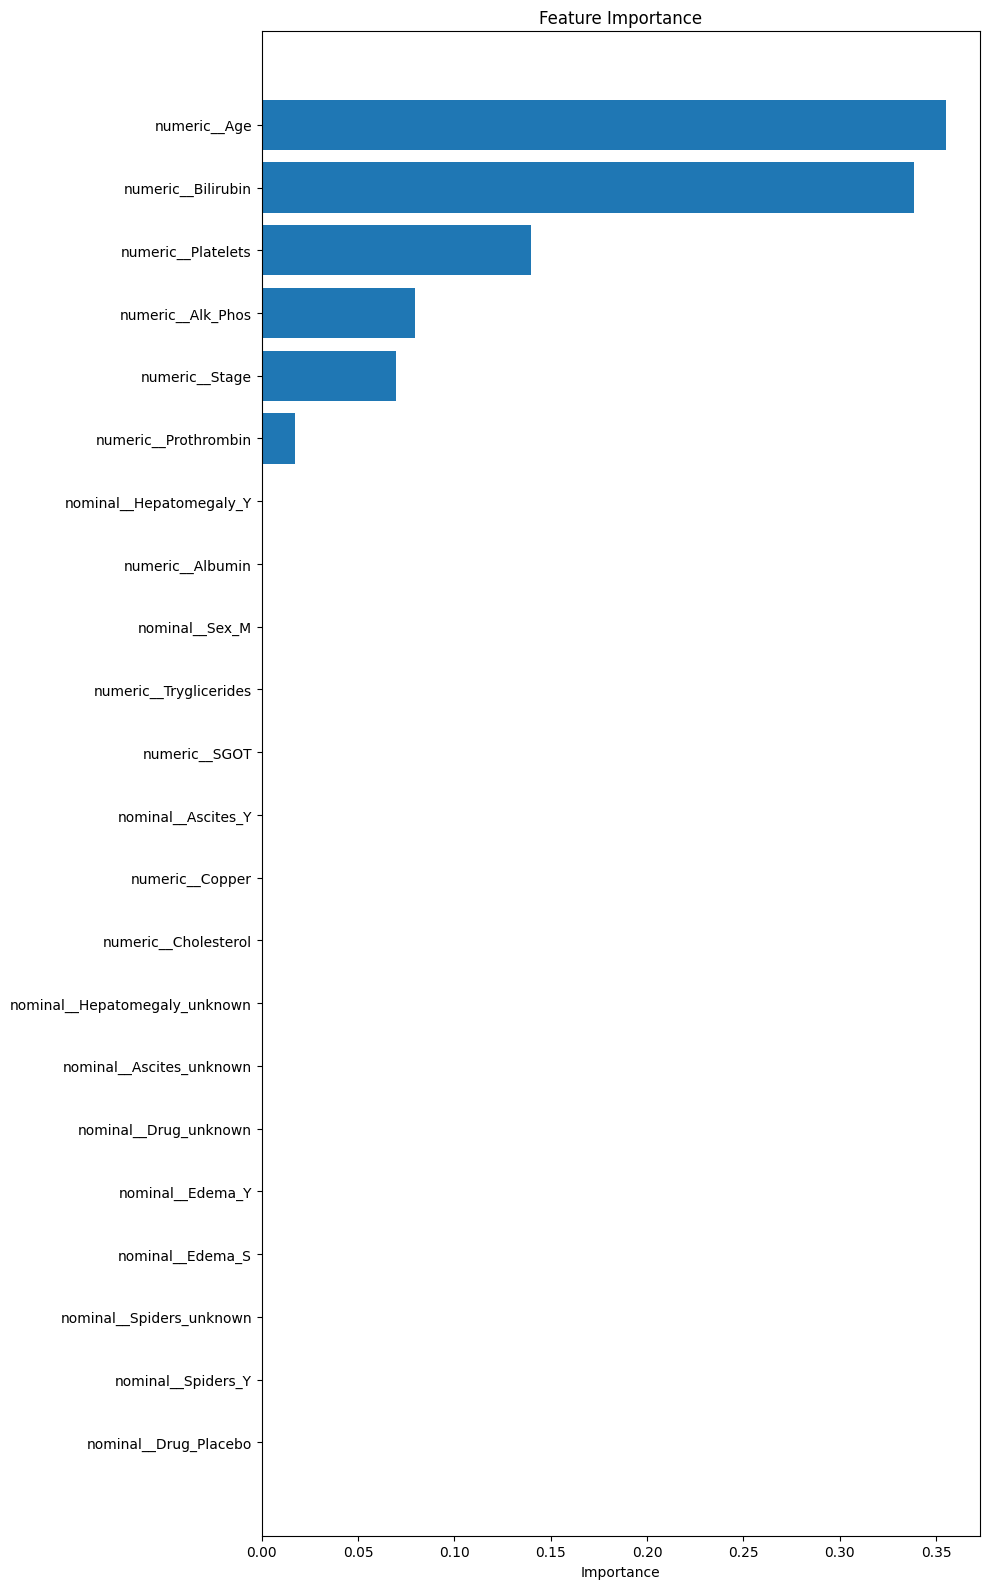

In [134]:
feature_importance = pd.DataFrame({
    'feature': x_features,
    'importance': model.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=False).head(50)

print(feature_importance.head(30))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 16))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### So far the 2 good candidates are the tuned Logistic regression model and the tuned Decision Tree model
|Notes|Tuned LR model|Tuned DT model|
|-------------------------|---------------------------------------|---------------------------------------|
|Class 0 (death) clinically most important class|21 correctly predicted|25 correctly predicted|
|Class 0 (death) clinically most important class Recall|21/32 66%|25/32 78%|
|Overall|Slightly better with class 2 being predicted although low score|class 2 completely ignored|

# If class 0 (death) prediction is the key the tuned decision tree will be chosen